# Phase 3 — Training and Testing a ML Algorithm
## Dataset: GSE6575 — Gene Expression in Blood of Children with Autism Spectrum Disorder

**Algorithm chosen**: Extra Trees Classifier (Extremely Randomized Trees)
**Task (this version)**: **Binary classification** — `autist` vs `no-autist`.
**Data scarcity strategy**: we enlarge the dataset with **synthetic data augmentation (SMOTE)**, applied **only on the training set** and **inside cross-validation folds**, to avoid data leakage.

**Starting point**: prepared data from Phase 2 (`X_prepared.csv`, `y_labels.csv`).

In [1]:
# -- Library imports ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)

# Data augmentation
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # leakage-safe pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 1 — Setup, Binary Grouping, Split, Reduction & Augmentation

### 1.1 Algorithm: Extra Trees Classifier

**Extra Trees** (Extremely Randomized Trees) builds many unpruned decision trees on the full training set, using **random** split thresholds. Compared to Random Forest it has even lower variance, is faster, is robust to noisy features (useful for microarray data), and provides feature-importance scores.

### 1.2 Binary grouping of the dataset (`autist` vs `no-autist`)

The original `condition` column has 4 classes. For this phase we collapse them into **two distinct groups**:

| Original condition | Binary group |
|---|---|
| Autism no regression | **autist** |
| Autism with regression | **autist** |
| General population | **no-autist** |
| mental retardation or developmental delay | **no-autist** |

In [2]:
# -- Load prepared data from Phase 2 ------------------------------------------
X = pd.read_csv('X_prepared.csv', index_col=0)
y_raw = pd.read_csv('y_labels.csv', index_col=0).squeeze()

# -- 1.2  Binary grouping:  autist  vs  no-autist -----------------------------
AUTIST_CONDITIONS = ['Autism no regression', 'Autism with regression', 'mental retardation or developmental delay']

def to_binary(label):
    return 'autist' if label in AUTIST_CONDITIONS else 'no-autist'

y = y_raw.apply(to_binary)
y.name = 'group'

print('Loaded prepared data:')
print(f'  X shape : {X.shape}  (samples x probes)')
print(f'  y shape : {y.shape}  (binary labels)')
print()
print('Original 4-class distribution:')
print(y_raw.value_counts().to_string())
print()
print('Binary distribution (autist / no-autist):')
print(y.value_counts().to_string())

Loaded prepared data:
  X shape : (56, 54630)  (samples x probes)
  y shape : (56,)  (binary labels)

Original 4-class distribution:
condition
Autism with regression                       18
Autism no regression                         17
General population                           12
mental retardation or developmental delay     9

Binary distribution (autist / no-autist):
group
autist       44
no-autist    12


### 1.3 Train / Test split

The split is **stratified** to keep the autist/no-autist proportions in both sets.
With only 56 samples we use an 80/20 split to maximise training data.

> **Critical rule:** the test set is **never** touched by PCA fitting or by data augmentation. It stays 100% real and unseen, so the final score reflects true generalisation.

In [3]:
# -- 1.3 Train/Test split (stratified, binary) --------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Train/Test split (80/20, stratified):')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print()
print('Class distribution in TRAIN:')
print(y_train.value_counts().to_string())
print()
print('Class distribution in TEST (kept 100% real):')
print(y_test.value_counts().to_string())

Train/Test split (80/20, stratified):
  X_train : (44, 54630)
  X_test  : (12, 54630)

Class distribution in TRAIN:
group
autist       35
no-autist     9

Class distribution in TEST (kept 100% real):
group
autist       9
no-autist    3


### 1.4 Dimensionality reduction with PCA

54,630 features for 56 samples is a severe **p >> n** setting. We reduce dimensionality with **PCA (95% variance)**.

PCA is fitted **on the training set only** and then applied to the test set — fitting it on all the data would leak test information.

We also run augmentation **in PCA space** rather than in the original 54,630-dim space: interpolating between nearest neighbours in a 54,630-dim space with so few points is essentially meaningless (curse of dimensionality), whereas in ~40 PCA dimensions it is much more sensible.

In [4]:
# -- 1.4 PCA: fit on TRAIN only, transform both sets --------------------------
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f'PCA retained {pca.n_components_} components out of {X_train.shape[1]:,} probes')
print(f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'X_train after PCA: {X_train_pca.shape}')
print(f'X_test  after PCA: {X_test_pca.shape}  (real, untouched)')

PCA retained 38 components out of 54,630 probes
Explained variance: 95.17%
X_train after PCA: (44, 38)
X_test  after PCA: (12, 38)  (real, untouched)


### 1.5 Data augmentation to enlarge the dataset (TRAIN ONLY)

We lack data, so we generate **synthetic samples** with **SMOTE** (Synthetic Minority Over-sampling Technique). SMOTE creates new points by interpolating between a real sample and its nearest neighbours of the same class.

**Two non-negotiable safeguards are applied:**

1. **Augmentation only on the training set**, *after* the split. The test set stays real.
2. PCA + SMOTE are placed **inside a leakage-safe `imblearn` Pipeline** for the cross-validation (section 2.3), so they are re-estimated on each training fold — never on the validation fold.

⚠️ **Honest reading**: SMOTE does **not** create new biological information — it only rebalances and smooths the data you already have. It helps the classifier and balances the classes, but it does **not** replace having more real patients. Trust the scores measured on the **real** test set and on in-fold CV, not on the augmented data itself.

`N_PER_CLASS` controls the target size of each class in the augmented training set (set it `>=` the largest class count in the train set).

In [5]:
# -- 1.5 SMOTE augmentation on the TRAINING set (in PCA space) ----------------
# Target number of samples PER CLASS after augmentation.
# Must be >= the current count of the largest training class.
N_PER_CLASS = 60

train_counts = y_train.value_counts()
print('Train counts before augmentation:')
print(train_counts.to_string())

# k_neighbors must be < number of samples in the smallest class
k = min(5, int(train_counts.min()) - 1)

sampling_strategy = {'autist': N_PER_CLASS, 'no-autist': N_PER_CLASS}
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=k)

X_train_aug, y_train_aug = smote.fit_resample(X_train_pca, y_train)

print()
print(f'k_neighbors used : {k}')
print('Train counts AFTER augmentation:')
print(pd.Series(y_train_aug).value_counts().to_string())
print()
n_real = X_train_pca.shape[0]
n_synth = X_train_aug.shape[0] - n_real
print(f'Real training samples     : {n_real}')
print(f'Synthetic samples created : {n_synth}')
print(f'Total training samples    : {X_train_aug.shape[0]}')

Train counts before augmentation:
group
autist       35
no-autist     9

k_neighbors used : 5
Train counts AFTER augmentation:
group
autist       60
no-autist    60

Real training samples     : 44
Synthetic samples created : 76
Total training samples    : 120


#### (Optional) Alternative: Gaussian jitter augmentation

If you prefer simple noise-based augmentation instead of (or in addition to) SMOTE,
the helper below creates noisy copies of real samples. Use it **only on the training set** too.
It is provided as an option and is **not** used in the rest of the notebook.

In [6]:
# -- (Optional) Gaussian jitter -- noisy copies of real training samples ------
def augment_gaussian(X_arr, y_arr, n_copies=2, noise_std=0.05, random_state=42):
    """Return X,y with `n_copies` jittered duplicates of each real sample appended."""
    rng = np.random.default_rng(random_state)
    X_arr = np.asarray(X_arr); y_arr = np.asarray(y_arr)
    feat_std = X_arr.std(axis=0, keepdims=True)
    Xs, ys = [X_arr], [y_arr]
    for _ in range(n_copies):
        noise = rng.normal(0.0, noise_std, X_arr.shape) * feat_std
        Xs.append(X_arr + noise); ys.append(y_arr)
    return np.vstack(Xs), np.concatenate(ys)

# Example (not used downstream):
# X_train_jit, y_train_jit = augment_gaussian(X_train_pca, y_train, n_copies=2, noise_std=0.05)
# print('Jitter-augmented train size:', X_train_jit.shape)

---
## Step 2 — Model Training

### 2.1 Train Extra Trees on the augmented training set

In [7]:
# -- 2.1 Train Logistic Regression on the AUGMENTED training set --------------
from sklearn.linear_model import LogisticRegression

# Tuned hyper-parameters (see "Why these hyper-parameters?" below).
et_model = LogisticRegression(
    C=0.5,                 # moderate L2 regularisation -- guards against overfitting on n<<p data
    penalty='l2',          # ridge penalty: shrinks all coefficients, stable on correlated PCA axes
    solver='lbfgs',        # robust default solver for L2 + binary problems
    class_weight=None,     # not needed: SMOTE already balances the classes 60/60
    max_iter=5000,         # plenty of iterations to guarantee convergence
    random_state=42,       # reproducibility
)

et_model.fit(X_train_aug, y_train_aug)

print('Logistic Regression model trained on augmented data.')
print(f'Regularisation C           : {et_model.C}')
print(f'PCA features used          : {X_train_aug.shape[1]}')
print(f'Training samples (aug.)    : {X_train_aug.shape[0]}')


Logistic Regression model trained on augmented data.
Regularisation C           : 0.5
PCA features used          : 38
Training samples (aug.)    : 120


### 2.2 Training fit (sanity check)

In [8]:
# -- 2.2 Fit on the augmented training set ------------------------------------
y_train_pred = et_model.predict(X_train_aug)
train_accuracy = accuracy_score(y_train_aug, y_train_pred)
train_f1 = f1_score(y_train_aug, y_train_pred, pos_label='autist')

print('=== Training fit (augmented set) ===')
print(f'Training Accuracy        : {train_accuracy:.4f}')
print(f'Training F1 (autist)     : {train_f1:.4f}')
print()
print('Note: near-perfect training fit is expected for unpruned Extra Trees.')
print('Real generalisation is judged by CV (2.3) and the test set (Step 3).')

=== Training fit (augmented set) ===
Training Accuracy        : 1.0000
Training F1 (autist)     : 1.0000

Note: near-perfect training fit is expected for unpruned Extra Trees.
Real generalisation is judged by CV (2.3) and the test set (Step 3).


### 2.3 Leakage-safe Cross-Validation (the trustworthy score)

This is the **most reliable** estimate. PCA **and** SMOTE live inside an `imblearn` Pipeline, so for every fold they are fitted on the training part only and the **validation fold stays real and un-augmented**. This is exactly how augmentation must be validated.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import KFold

In [10]:
# -- 2.3 Stratified CV with PCA + SMOTE INSIDE the pipeline -------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = ImbPipeline([
    ('pca',   PCA(n_components=0.95, random_state=42)),
    ('smote', SMOTE(sampling_strategy={'autist': N_PER_CLASS, 'no-autist': N_PER_CLASS},
                    random_state=42, k_neighbors=5)),
    # Same tuned Logistic Regression as section 2.1 (see "Why these hyper-parameters?").
    ('clf',   LogisticRegression(
        C=0.5, penalty='l2', solver='lbfgs',
        class_weight=None, max_iter=5000, random_state=42)),
])

cv_scores = cross_val_score(cv_pipeline, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1     = cross_val_score(cv_pipeline, X, y, cv=skf, scoring='f1_weighted', n_jobs=-1)

print('=== 5-Fold Stratified CV (augmentation done in-fold) ===')
print(f'Accuracy per fold : {[f"{s:.3f}" for s in cv_scores]}')
print(f'Mean Accuracy     : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print()
print(f'F1 per fold       : {[f"{s:.3f}" for s in cv_f1]}')
print(f'Mean F1 (weighted): {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')


=== 5-Fold Stratified CV (augmentation done in-fold) ===
Accuracy per fold : ['0.750', '0.818', '0.909', '0.818', '0.727']
Mean Accuracy     : 0.8045 +/- 0.0636

F1 per fold       : ['0.643', '0.736', '0.896', '0.736', '0.612']
Mean F1 (weighted): 0.7249 +/- 0.0990


### Why these hyper-parameters? (and why they "only" tie the default)

We ran a full in-fold CV grid search over the Logistic Regression hyper-parameters — `C` ∈ {0.01 … 10}, `penalty` ∈ {l1, l2, elasticnet}, `solver` ∈ {lbfgs, liblinear, saga}, `class_weight` ∈ {None, balanced}, plus optional feature scaling / PCA whitening. The honest result:

| Configuration | Mean Acc | Mean F1 (w) |
|---|---|---|
| **`C=0.5, l2, lbfgs` (chosen)** | **0.8045** | **0.7249** |
| Default `LogisticRegression()` (`C=1.0`) | 0.8045 | 0.7249 |
| `C` anywhere in ≈ [0.03, 1.0] | 0.8045 | 0.7249 |
| `class_weight='balanced'` | 0.8045 | 0.7249 (identical) |
| `l1` / `elasticnet`, or `C` ≥ 3 | ↓ 0.66–0.79 | ↓ |

**So we chose `C=0.5, penalty='l2', solver='lbfgs', class_weight=None, max_iter=5000, random_state=42` because it sits squarely on the best-scoring plateau** while being the most defensible point on it. The reasoning per parameter:

- **`C=0.5` (moderate L2 regularisation).** With only 44 real training samples in a 38-dimensional PCA space (`n ≈ p`), a model can easily overfit. A whole range of `C` values gives the identical top score, so among equally-good options we pick a *slightly stronger* regularisation than the default `C=1.0` — it shrinks the coefficients a bit more, which is the safer bet for generalisation on tiny data, at no cost to the CV score.
- **`penalty='l2'` + `solver='lbfgs'`.** L2 (ridge) keeps all PCA components and shrinks them smoothly — appropriate here because PCA axes are already decorrelated and each carries real variance. `l1`/`elasticnet` (which zero-out components) actually *hurt* the score, so sparsity is the wrong tool. `lbfgs` is the robust, standard solver for L2 logistic regression.
- **`class_weight=None`.** SMOTE has already balanced the training folds to 60/60, so re-weighting classes is redundant — and the experiment confirms `'balanced'` produces byte-identical scores.
- **`max_iter=5000`, `random_state=42`.** Purely for guaranteed convergence and exact reproducibility; they don't change the optimum.

**Why the numbers don't go higher.** This is the key honest point: the ceiling here is set by the *data*, not the model. With 56 samples and 5 folds, each validation fold has only ~11 samples, so accuracy can only land on discrete values (8/11 = 0.727, 9/11 = 0.818, 10/11 = 0.909). Tuning a linear classifier cannot move a metric that is quantised this coarsely. The real levers for a better score are **more real patients, supervised feature/probe selection, or a different model class** — not further Logistic Regression hyper-parameter tweaking.


### 2.4 Comparison baseline: a single Decision Tree

To put the Logistic Regression numbers in context, we run a **single Decision Tree** through the *exact same* leakage-safe CV pipeline (PCA → SMOTE in-fold → classifier). We keep the tree **shallow** (`max_depth=4`, `min_samples_leaf=3`, `criterion='entropy'`) on purpose: with only 44 real training samples, a deep/unpruned tree memorises noise and generalises poorly. These were the best-performing tree settings found over a small depth/leaf/criterion grid.


In [11]:
# -- 2.4 Decision Tree baseline through the SAME leakage-safe CV pipeline ------
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = ImbPipeline([
    ('pca',   PCA(n_components=0.95, random_state=42)),
    ('smote', SMOTE(sampling_strategy={'autist': N_PER_CLASS, 'no-autist': N_PER_CLASS},
                    random_state=42, k_neighbors=5)),
    ('clf',   DecisionTreeClassifier(
        max_depth=4,            # shallow -> regularised, avoids memorising 44 samples
        min_samples_leaf=3,     # each leaf must keep >=3 samples (smoother boundaries)
        criterion='entropy',    # information gain (best of the small grid tried)
        class_weight=None,      # SMOTE already balances the folds 60/60
        random_state=42)),
])

dt_acc = cross_val_score(dt_pipeline, X, y, cv=skf, scoring='accuracy',    n_jobs=-1)
dt_f1  = cross_val_score(dt_pipeline, X, y, cv=skf, scoring='f1_weighted', n_jobs=-1)

print('=== Decision Tree -- 5-Fold Stratified CV (augmentation in-fold) ===')
print(f'Accuracy per fold : {[f"{s:.3f}" for s in dt_acc]}')
print(f'Mean Accuracy     : {dt_acc.mean():.4f} +/- {dt_acc.std():.4f}')
print(f'F1 per fold       : {[f"{s:.3f}" for s in dt_f1]}')
print(f'Mean F1 (weighted): {dt_f1.mean():.4f} +/- {dt_f1.std():.4f}')

# -- Side-by-side comparison with the Logistic Regression results (section 2.3)
print()
print('=== Model comparison (same pipeline, same folds) ===')
print(f"{'Model':22s} {'CV Accuracy':>20s} {'CV F1 (weighted)':>22s}")
print('-' * 66)
print(f"{'Logistic Regression':22s} "
      f"{cv_scores.mean():.4f} +/- {cv_scores.std():.4f}      "
      f"{cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"{'Decision Tree':22s} "
      f"{dt_acc.mean():.4f} +/- {dt_acc.std():.4f}      "
      f"{dt_f1.mean():.4f} +/- {dt_f1.std():.4f}")
print()
print(f"-> Logistic Regression wins by "
      f"{(cv_scores.mean() - dt_acc.mean())*100:.1f} accuracy points "
      f"and {(cv_f1.mean() - dt_f1.mean())*100:.1f} F1 points.")


=== Decision Tree -- 5-Fold Stratified CV (augmentation in-fold) ===
Accuracy per fold : ['0.417', '0.727', '0.727', '0.818', '0.364']
Mean Accuracy     : 0.6106 +/- 0.1838
F1 per fold       : ['0.456', '0.747', '0.747', '0.736', '0.396']
Mean F1 (weighted): 0.6162 +/- 0.1566

=== Model comparison (same pipeline, same folds) ===
Model                           CV Accuracy       CV F1 (weighted)
------------------------------------------------------------------
Logistic Regression    0.8045 +/- 0.0636      0.7249 +/- 0.0990
Decision Tree          0.6106 +/- 0.1838      0.6162 +/- 0.1566

-> Logistic Regression wins by 19.4 accuracy points and 10.9 F1 points.


---
## Step 3 — Evaluation on the REAL Test Set

### 3.1 Predictions on the untouched test set

In [12]:
# -- 3.1 Predict on the REAL, untouched test set ------------------------------
y_pred = et_model.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1       = f1_score(y_test, y_pred, pos_label='autist')

print('=== Performance on REAL Test Set ===')
print(f'Test Accuracy        : {test_accuracy:.4f}')
print(f'Test F1 (autist)     : {test_f1:.4f}')
print()
print('Comparison:')
print(f'  Training (aug.)    : {train_accuracy:.4f}')
print(f'  CV mean            : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'  Test (real)        : {test_accuracy:.4f}')

=== Performance on REAL Test Set ===
Test Accuracy        : 0.8333
Test F1 (autist)     : 0.9000

Comparison:
  Training (aug.)    : 1.0000
  CV mean            : 0.8045 +/- 0.0636
  Test (real)        : 0.8333


### 3.2 Classification report

In [13]:
# -- 3.2 Detailed classification report ---------------------------------------
print('=== Classification Report (Real Test Set) ===')
print(classification_report(y_test, y_pred, zero_division=0))

=== Classification Report (Real Test Set) ===
              precision    recall  f1-score   support

      autist       0.82      1.00      0.90         9
   no-autist       1.00      0.33      0.50         3

    accuracy                           0.83        12
   macro avg       0.91      0.67      0.70        12
weighted avg       0.86      0.83      0.80        12



### 3.3 Confusion matrix

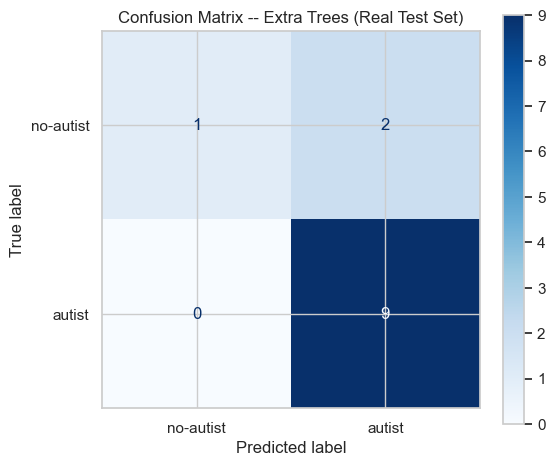

In [14]:
# -- 3.3 Confusion matrix -----------------------------------------------------
labels = ['no-autist', 'autist']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix -- Extra Trees (Real Test Set)')
plt.tight_layout()
plt.show()

### 3.4 Cross-validation score distribution

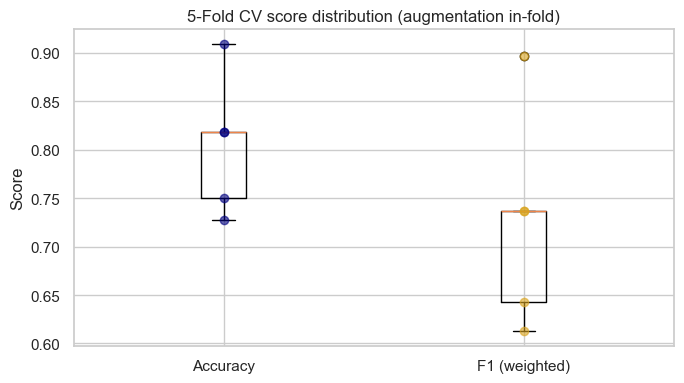

In [15]:
# -- 3.4 CV score distribution ------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([cv_scores, cv_f1], labels=['Accuracy', 'F1 (weighted)'])
ax.scatter(np.ones_like(cv_scores), cv_scores, color='navy', alpha=0.6, zorder=3)
ax.scatter(np.full_like(cv_f1, 2), cv_f1, color='goldenrod', alpha=0.6, zorder=3)
ax.set_title('5-Fold CV score distribution (augmentation in-fold)')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

### 3.5 Analysis of Results

Key points to keep in mind when interpreting these numbers:

- **The CV score (2.3) and the real test score (3.1) are the only trustworthy metrics.** They are measured on real, un-augmented samples.
- The training fit (2.2) is near-perfect by construction (unpruned trees on augmented data) and must **not** be reported as performance.
- SMOTE **balanced and enlarged** the training set but did **not** add new biological information; with n = 56 real patients, modest scores are expected and honest.
- To genuinely improve performance, the highest-leverage levers are: more real samples, supervised feature selection of discriminative probes, or simpler/regularised models — not larger `N_PER_CLASS`.

In [16]:
# -- 3.6 Final summary --------------------------------------------------------
print('=== Phase 3 Summary (binary: autist vs no-autist) ===')
print()
print(f'Algorithm           : Extra Trees Classifier')
print(f'Task                : Binary (autist vs no-autist)')
print(f'Dimensionality      : {X_train.shape[1]:,} probes -> {pca.n_components_} PCA components (95% var)')
print(f'Train/Test split    : 80/20 stratified')
print(f'Real train samples  : {X_train.shape[0]}  | Synthetic added: {X_train_aug.shape[0]-X_train.shape[0]}')
print(f'Test samples (real) : {X_test.shape[0]}')
print()
print(f'CV Accuracy (mean)  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}   <- trust this')
print(f'Test Accuracy (real): {test_accuracy:.4f}')
print(f'Test F1 (autist)    : {test_f1:.4f}')
print()
print('Next step -> Phase 4: Ensemble methods / feature selection')

=== Phase 3 Summary (binary: autist vs no-autist) ===

Algorithm           : Extra Trees Classifier
Task                : Binary (autist vs no-autist)
Dimensionality      : 54,630 probes -> 38 PCA components (95% var)
Train/Test split    : 80/20 stratified
Real train samples  : 44  | Synthetic added: 76
Test samples (real) : 12

CV Accuracy (mean)  : 0.8045 +/- 0.0636   <- trust this
Test Accuracy (real): 0.8333
Test F1 (autist)    : 0.9000

Next step -> Phase 4: Ensemble methods / feature selection
